# Vision Transformers (ViT and Beyond)

## Why Transformers for Vision?
CNNs have inductive biases: locality and translation equivariance. Transformers have **global receptive field from layer 1** and learn relationships across the entire image. With enough data, they outperform CNNs.

---

## ViT Vision Transformer (2020)

**Core idea**: split image into fixed-size patches, treat each patch as a "token", feed to a standard Transformer encoder.

**Patch embedding**: image $x \in \mathbb{R}^{H \times W \times C}$ → $N = \frac{HW}{P^2}$ patches of size $P \times P$:
$$z_0 = [x_{class};\ x_p^1 E;\ x_p^2 E;\ \ldots;\ x_p^N E] + E_{pos}$$

where $E \in \mathbb{R}^{(P^2 \cdot C) \times D}$ is patch embedding, $E_{pos} \in \mathbb{R}^{(N+1) \times D}$ is positional embedding.

**CLS token**: a learnable embedding prepended to the sequence, whose final state is used for classification.

**Transformer encoder** (L layers):
$$z'_\ell = \text{MSA}(\text{LN}(z_{\ell-1})) + z_{\ell-1}$$
$$z_\ell = \text{MLP}(\text{LN}(z'_\ell)) + z'_\ell$$

**Self-attention** (scaled dot-product):
$$\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**ViT variants**:

| Model | Layers | Hidden | Heads | Params | Top-1 |
|-------|--------|--------|-------|--------|-------|
| ViT-Ti/16 | 12 | 192 | 3 | 6M | 72.2% |
| ViT-S/16 | 12 | 384 | 6 | 22M | 79.9% |
| ViT-B/16 | 12 | 768 | 12 | 86M | 81.8% |
| ViT-L/16 | 24 | 1024 | 16 | 307M | 82.6% |
| ViT-H/14 | 32 | 1280 | 16 | 632M | 85.1% |

---

## Swin Transformer (2021)

Introduces **shifted window attention**: self-attention within local windows, windows shift between layers to enable cross-window connections.

- **Hierarchical**: produces multi-scale feature maps (like CNNs), compatible with detection/segmentation heads
- Window size $M \times M$ → complexity $O(M^2 N)$ vs global $O(N^2)$
- Patch merging: merges 2×2 patches → hierarchical representations

**Relative position bias**:
$$\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d}} + B\right)V$$

---

## DeiT Data-efficient Image Transformers (2021)

Shows ViT can work with ImageNet-only training (no JFT-300M) using:
- Knowledge distillation from a CNN teacher
- **Distillation token** alongside CLS token
- Strong augmentation: RandAugment, CutMix, Mixup, random erasing

---

## MAE Masked Autoencoder (2021)

Self-supervised pre-training: mask 75% of patches, reconstruct pixel values of masked patches.

- Asymmetric encoder-decoder: encoder only sees unmasked tokens
- High masking ratio forces learning of holistic representations
- Loss: MSE on normalized pixel values of masked patches only

$$\mathcal{L} = \frac{1}{|M|} \sum_{p \in M} ||x_p - \hat{x}_p||^2$$

---

## CLIP Contrastive Language-Image Pretraining (2021)

Jointly trains image encoder and text encoder with contrastive loss on 400M image-text pairs.

**InfoNCE Loss** (symmetric):
$$L_I = -\frac{1}{N}\sum_i \log \frac{e^{s(I_i, T_i)/\tau}}{\sum_j e^{s(I_i, T_j)/\tau}}$$
$$L_T = -\frac{1}{N}\sum_i \log \frac{e^{s(I_i, T_i)/\tau}}{\sum_j e^{s(I_j, T_i)/\tau}}$$
$$L = \frac{L_I + L_T}{2}$$

where $s(I, T) = \frac{f_I(I)^T f_T(T)}{||f_I(I)|| \cdot ||f_T(T)||}$ (cosine similarity), $\tau$ = learned temperature.

**Zero-shot classification**: compute cosine similarity between image embedding and text embeddings of class descriptions.

---

## Model Comparison

| Model | Type | Innovation | Best For |
|-------|------|-----------|----------|
| ViT | Supervised | Patches as tokens | Classification |
| DeiT | Supervised | Distillation token | Data-efficient |
| Swin | Supervised | Shifted windows | Detection/Seg |
| BEiT | Self-supervised | BERT for vision | Pre-training |
| MAE | Self-supervised | High-ratio masking | Pre-training |
| DINO | Self-supervised | Self-distillation | Features |
| DINOv2 | Self-supervised | Curated data | Universal features |
| CLIP | Supervised | Language-image | Zero-shot |
| SigLIP | Supervised | Sigmoid loss | Better CLIP |
| EVA | Supervised | CLIP-guided | Unified backbone |


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# Patch Embedding from Scratch
# ============================================================

class PatchEmbedding(nn.Module):
    """
    Split image into patches and project to D dimensions.
    Image: (B, C, H, W) -> Patches: (B, N, D)
    where N = (H/P) * (W/P)
    """
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=768):
        super().__init__()
        self.img_size   = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        # Conv2d with kernel=stride=patch_size performs patch extraction + linear projection
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        B, C, H, W = x.shape
        x = self.proj(x)           # (B, D, H/P, W/P)
        x = x.flatten(2)           # (B, D, N)
        x = x.transpose(1, 2)      # (B, N, D)
        return x


# Test
patch_embed = PatchEmbedding(img_size=224, patch_size=16, in_channels=3, embed_dim=768)
x = torch.randn(2, 3, 224, 224)
patches = patch_embed(x)
print(f'Image: {x.shape}')
print(f'Patches: {patches.shape}')  # (2, 196, 768) 196 = 14*14 patches

Image: torch.Size([2, 3, 224, 224])
Patches: torch.Size([2, 196, 768])


In [3]:
# ============================================================
# Multi-Head Self-Attention
# ============================================================

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=768, num_heads=12, dropout=0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = self.head_dim ** -0.5

        self.qkv    = nn.Linear(embed_dim, embed_dim * 3)
        self.proj   = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x)                              # (B, N, 3D)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)              # (3, B, H, N, head_dim)
        q, k, v = qkv.unbind(0)                        # each (B, H, N, head_dim)

        # Scaled dot-product attention
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B, H, N, N)
        attn = attn.softmax(dim=-1)
        attn = self.dropout(attn)

        x = (attn @ v)                                 # (B, H, N, head_dim)
        x = x.transpose(1, 2).reshape(B, N, D)         # (B, N, D)
        x = self.proj(x)
        return x, attn


mhsa = MultiHeadSelfAttention(embed_dim=768, num_heads=12)
out, attn_weights = mhsa(patches)
print(f'MHSA output: {out.shape}')        # (2, 196, 768)
print(f'Attention:   {attn_weights.shape}')  # (2, 12, 196, 196)

MHSA output: torch.Size([2, 196, 768])
Attention:   torch.Size([2, 12, 196, 196])


In [4]:
# ============================================================
# Full ViT Implementation
# ============================================================

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        mlp_dim = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        attn_out, _ = self.attn(self.norm1(x))
        x = x + attn_out                      # Residual
        x = x + self.mlp(self.norm2(x))       # Residual
        return x


class VisionTransformer(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3,
                 num_classes=1000, embed_dim=768, depth=12,
                 num_heads=12, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches

        # Learnable CLS token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # Learnable positional embedding (+1 for CLS)
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop  = nn.Dropout(dropout)

        # Transformer encoder
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        # Classification head
        self.head = nn.Linear(embed_dim, num_classes)

        # Initialize weights
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)                          # (B, N, D)

        # Prepend CLS token
        cls = self.cls_token.expand(B, -1, -1)           # (B, 1, D)
        x = torch.cat([cls, x], dim=1)                   # (B, N+1, D)
        x = self.pos_drop(x + self.pos_embed)            # Add positional embedding

        # Transformer encoder
        for block in self.blocks:
            x = block(x)

        x = self.norm(x)
        cls_out = x[:, 0]                                 # CLS token output
        return self.head(cls_out)


# Test ViT-B/16
vit = VisionTransformer(
    img_size=224, patch_size=16, in_channels=3,
    num_classes=1000, embed_dim=768, depth=12, num_heads=12
)
x = torch.randn(2, 3, 224, 224)
out = vit(x)
print(f'ViT-B/16 output: {out.shape}')   # (2, 1000)
total = sum(p.numel() for p in vit.parameters())
print(f'Total params:    {total/1e6:.1f}M')  # ~86M

ViT-B/16 output: torch.Size([2, 1000])
Total params:    86.6M


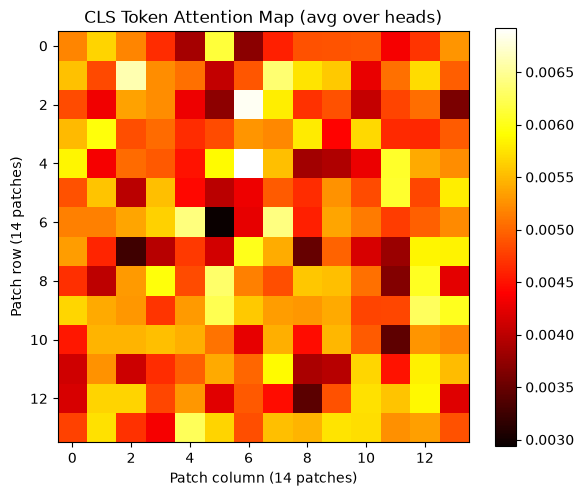

In [5]:
# ============================================================
# Attention Map Visualization
# ============================================================

def visualize_attention(attn_weights, patch_size=16, img_size=224):
    """
    Visualize attention from CLS token to all patches.
    attn_weights: (num_heads, N+1, N+1)
    """
    num_patches = (img_size // patch_size) ** 2
    # Get attention from CLS (index 0) to all patches
    cls_attn = attn_weights[:, 0, 1:]          # (num_heads, N)
    cls_attn = cls_attn.mean(0)                 # Average over heads: (N,)
    num_h = img_size // patch_size
    attn_map = cls_attn.reshape(num_h, num_h).detach().numpy()

    plt.figure(figsize=(6, 5))
    plt.imshow(attn_map, cmap='hot', interpolation='nearest')
    plt.colorbar()
    plt.title('CLS Token Attention Map (avg over heads)')
    plt.xlabel(f'Patch column ({num_h} patches)')
    plt.ylabel(f'Patch row ({num_h} patches)')
    plt.tight_layout(); plt.show()


# Get attention weights from first block
with torch.no_grad():
    x_test = torch.randn(1, 3, 224, 224)
    x_emb  = vit.patch_embed(x_test)
    cls    = vit.cls_token.expand(1, -1, -1)
    x_emb  = torch.cat([cls, x_emb], dim=1) + vit.pos_embed
    _, attn = vit.blocks[0].attn(vit.blocks[0].norm1(x_emb))
    visualize_attention(attn[0])  # First image in batch

In [6]:
# ============================================================
# CLIP Zero-Shot Classification Demo
# ============================================================
# pip install open-clip-torch

clip_code = '''
import open_clip
import torch
from PIL import Image

# Load CLIP model
model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="openai"
)
tokenizer = open_clip.get_tokenizer("ViT-B-32")
model.eval()

# Image
image = preprocess(Image.open("cat.jpg")).unsqueeze(0)

# Text descriptions for zero-shot classification
classes = ["a cat", "a dog", "a bird", "a car", "an airplane"]
text = tokenizer([f"a photo of {c}" for c in classes])

with torch.no_grad():
    image_features = model.encode_image(image)
    text_features  = model.encode_text(text)

    # Normalize
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    text_features  = text_features  / text_features.norm(dim=-1, keepdim=True)

    # Cosine similarity -> softmax probabilities
    logits_per_image = (100.0 * image_features @ text_features.T).softmax(dim=-1)

for cls, prob in zip(classes, logits_per_image[0]):
    print(f"{cls:20s}: {prob.item():.3f}")
'''
print('CLIP zero-shot classification code:')
print(clip_code)

# Available CLIP variants
print('\nCLIP Model Variants (open_clip):')
models_info = [
    ('ViT-B/32', 'openai', '86M img + 63M txt', 'Fast, standard'),
    ('ViT-B/16', 'openai', '86M img + 63M txt', 'Better quality'),
    ('ViT-L/14', 'openai', '307M img', 'Best OpenAI CLIP'),
    ('ViT-H/14', 'laion2b_s32b_b79k', '632M img', 'LAION trained, very strong'),
    ('ViT-G/14', 'laion2b_s12b_b42k', '1B img', 'Largest open CLIP'),
]
for name, pretrained, size, note in models_info:
    print(f'  {name:<12} pretrained={pretrained:<30} {size:<25} {note}')

CLIP zero-shot classification code:

import open_clip
import torch
from PIL import Image

# Load CLIP model
model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="openai"
)
tokenizer = open_clip.get_tokenizer("ViT-B-32")
model.eval()

# Image
image = preprocess(Image.open("cat.jpg")).unsqueeze(0)

# Text descriptions for zero-shot classification
classes = ["a cat", "a dog", "a bird", "a car", "an airplane"]
text = tokenizer([f"a photo of {c}" for c in classes])

with torch.no_grad():
    image_features = model.encode_image(image)
    text_features  = model.encode_text(text)

    # Normalize
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    text_features  = text_features  / text_features.norm(dim=-1, keepdim=True)

    # Cosine similarity -> softmax probabilities
    logits_per_image = (100.0 * image_features @ text_features.T).softmax(dim=-1)

for cls, prob in zip(classes, logits_per_image[0]):
    print(f"{cls:20s}: 

In [7]:
# ============================================================
# Using timm for all Vision Transformer variants
# ============================================================
try:
    import timm
    vit_models = [
        'vit_tiny_patch16_224', 'vit_small_patch16_224',
        'vit_base_patch16_224', 'vit_large_patch16_224',
        'swin_tiny_patch4_window7_224', 'swin_base_patch4_window7_224',
        'deit_small_patch16_224', 'deit_base_patch16_224',
        'beit_base_patch16_224', 'convnext_base',
        'maxvit_tiny_tf_224', 'efficientvit_b1',
    ]
    print(f'{"Model":<45} {"Params":>10} {"Resolution"}')
    print('-' * 70)
    for name in vit_models:
        try:
            m = timm.create_model(name, pretrained=False)
            params = sum(p.numel() for p in m.parameters()) / 1e6
            cfg = m.default_cfg
            res = cfg.get('input_size', ('?','?','?'))[1]
            print(f'{name:<45} {params:>8.1f}M {res}x{res}')
        except Exception as e:
            print(f'{name:<45} {e}')
except ImportError:
    print('Install timm: pip install timm')

Model                                             Params Resolution
----------------------------------------------------------------------
vit_tiny_patch16_224                               5.7M 224x224


vit_small_patch16_224                             22.1M 224x224


vit_base_patch16_224                              86.6M 224x224


vit_large_patch16_224                            304.3M 224x224


swin_tiny_patch4_window7_224                      28.3M 224x224


...

deit_small_patch16_224                            22.1M 224x224


deit_base_patch16_224                             86.6M 224x224


beit_base_patch16_224                             86.5M 224x224


convnext_base                                     88.6M 224x224


maxvit_tiny_tf_224                                30.9M 224x224
efficientvit_b1                                    9.1M 224x224


## Additional Learning Resources

### Papers
- [ViT: An Image is Worth 16x16 Words](https://arxiv.org/abs/2010.11929) Dosovitskiy et al. 2020
- [DeiT: Training Data-Efficient Image Transformers](https://arxiv.org/abs/2012.12877) Touvron et al. 2021
- [Swin Transformer](https://arxiv.org/abs/2103.14030) Liu et al. 2021
- [Swin Transformer V2](https://arxiv.org/abs/2111.09883) Liu et al. 2022
- [BEiT: BERT Pre-training of Image Transformers](https://arxiv.org/abs/2106.08254) Bao et al. 2021
- [MAE: Masked Autoencoders Are Scalable Vision Learners](https://arxiv.org/abs/2111.06377) He et al. 2021
- [DINO: Self-Supervised Vision Transformers](https://arxiv.org/abs/2104.14294) Caron et al. 2021
- [DINOv2: Learning Robust Visual Features without Supervision](https://arxiv.org/abs/2304.07193) Oquab et al. 2023
- [CLIP: Learning Transferable Visual Models from Natural Language](https://arxiv.org/abs/2103.00020) Radford et al. 2021
- [SigLIP: Sigmoid Loss for Language-Image Pre-Training](https://arxiv.org/abs/2303.15343) Zhai et al. 2023
- [EVA: Exploring the Limits of Masked Visual Representation Learning](https://arxiv.org/abs/2211.07636) Fang et al. 2023
- [MaxViT: Multi-Axis Vision Transformer](https://arxiv.org/abs/2204.01697) Tu et al. 2022

### Implementations
- [timm library](https://timm.fast.ai/) 800+ vision models incl. all ViT variants
- [open_clip](https://github.com/mlfoundations/open_clip) Open source CLIP
- [HuggingFace Transformers Vision](https://huggingface.co/docs/transformers/model_doc/vit)
- [DINOv2 Official](https://github.com/facebookresearch/dinov2)

### Blog Posts
- [The Illustrated Vision Transformer](https://jalammar.github.io/illustrated-transformer/) Jay Alammar
- [Swin Transformer Explained](https://towardsdatascience.com/a-comprehensive-overview-of-the-swin-transformer-bcf1ee5e5bce)
- [Understanding CLIP](https://openai.com/research/clip)
